<a href="https://colab.research.google.com/github/Haniya-Imran/ML-Algorithms-Projects/blob/main/Financial_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Financial Fraud Detection Project**

# **Project Overview:**
This project focuses on building a machine learning model to detect fraudulent financial transactions. We use a dataset containing various transaction details to identify and predict potential fraud.

## **Contents:**
* Import Libraries
* Load Dataset
* Dataset Overview
* Exploratory Data Analysis (EDA)
* Data Preprocessing
* Feature Scaling
* Train-Test Split
* Model Training
* Model Evaluation
* Hyperparameter Tuning
* Pipeline
* Feature Importance
* Final Output
* Conclusion

### **Import Libraries:**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_curve, auc, precision_score, recall_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

### **Dataset load:**

In [ ]:
# Load the dataset
df = pd.read_csv('/content/finance_fraud_data.csv')

### **Dataset Overview:**

In [ ]:
display(df.head(2))

,Transaction_ID,Timestamp,Customer_ID,Amount,Merchant_Category,Distance_from_Home,Device_Type,IP_Risk_Score,Avg_Spending_Habit,Is_Weekend,Is_Night_Transaction,Is_Fraud
0,TRX-000001,2025-02-06 18:46:00,CUST-1727,1985.97,Luxury_Goods,0.0123,Android,0.89,94.75,0,0,1
1,TRX-000002,2025-03-25 09:19:00,CUST-1607,30.45,Food_Dining,0.0123,Android,0.85,26.00,0,0,0


In [ ]:
# Display the last 5 rows
display(df.tail(2))

,Transaction_ID,Timestamp,Customer_ID,Amount,Merchant_Category,Distance_from_Home,Device_Type,IP_Risk_Score,Avg_Spending_Habit,Is_Weekend,Is_Night_Transaction,Is_Fraud
14998,TRX-014999,2025-03-16 05:28:00,CUST-1681,23.01,Online_Services,0.0123,iOS,0.27,117.09,1,0,0
14999,TRX-015000,2025-02-13 00:33:00,CUST-1991,342.43,Electronics,0.0123,Web_Browser,0.27,102.41,0,1,0


In [ ]:
# Display the shape of the DataFrame (rows, columns)
display(df.shape)

(15000, 12)

In [ ]:
# Display the column names
display(df.columns.tolist())

['Transaction_ID',
 'Timestamp',
 'Customer_ID',
 'Amount',
 'Merchant_Category',
 'Distance_from_Home',
 'Device_Type',
 'IP_Risk_Score',
 'Avg_Spending_Habit',
 'Is_Weekend',
 'Is_Night_Transaction',
 'Is_Fraud']

In [ ]:
# Display concise summary of the DataFrame, including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Transaction_ID        15000 non-null  object 
 1   Timestamp             15000 non-null  object 
 2   Customer_ID           15000 non-null  object 
 3   Amount                15000 non-null  float64
 4   Merchant_Category     15000 non-null  object 
 5   Distance_from_Home    15000 non-null  float64
 6   Device_Type           15000 non-null  object 
 7   IP_Risk_Score         15000 non-null  float64
 8   Avg_Spending_Habit    15000 non-null  float64
 9   Is_Weekend            15000 non-null  int64  
 10  Is_Night_Transaction  15000 non-null  int64  
 11  Is_Fraud              15000 non-null  int64  
dtypes: float64(4), int64(3), object(5)
memory usage: 1.4+ MB


In [ ]:
# Display descriptive statistics for numerical columns
display(df.describe())

,Amount,Distance_from_Home,IP_Risk_Score,Avg_Spending_Habit,Is_Weekend,Is_Night_Transaction,Is_Fraud
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,197.627147,0.258520,0.501900,99.813583,0.286467,0.207800,0.122333
std,556.909653,1.058511,0.290001,29.930782,0.452125,0.405746,0.327681
min,2.580000,0.012300,0.000000,-36.680000,0.000000,0.000000,0.000000
25%,22.167500,0.012300,0.250000,79.700000,0.000000,0.000000,0.000000
50%,38.120000,0.012300,0.500000,100.050000,0.000000,0.000000,0.000000
75%,69.905000,0.012300,0.750000,120.050000,1.000000,0.000000,0.000000
max,7987.240000,4.808800,1.000000,200.550000,1.000000,1.000000,1.000000


In [ ]:
# Display the data types of each column
display(df.dtypes)

,0
Transaction_ID,object
Timestamp,object
Customer_ID,object
Amount,float64
Merchant_Category,object
Distance_from_Home,float64
Device_Type,object
IP_Risk_Score,float64
Avg_Spending_Habit,float64
Is_Weekend,int64


In [ ]:
# Display the count of missing values per column
display(df.isnull().sum())

,0
Transaction_ID,0
Timestamp,0
Customer_ID,0
Amount,0
Merchant_Category,0
Distance_from_Home,0
Device_Type,0
IP_Risk_Score,0
Avg_Spending_Habit,0
Is_Weekend,0


### **Data Cleaning:**

In [ ]:
# Count duplicate rows
duplicate_rows = df.duplicated().sum()
display(f"Number of duplicate rows: {duplicate_rows}")

'Number of duplicate rows: 0'

In [ ]:
# Remove duplicate rows if any exist
df_cleaned = df.drop_duplicates()
display(f"DataFrame shape after removing duplicates: {df_cleaned.shape}")

'DataFrame shape after removing duplicates: (15000, 12)'

In [ ]:
# Convert 'Timestamp' column to datetime objects
df_cleaned['Timestamp'] = pd.to_datetime(df_cleaned['Timestamp'])
display(df_cleaned.dtypes)

,0
Transaction_ID,object
Timestamp,datetime64[ns]
Customer_ID,object
Amount,float64
Merchant_Category,object
Distance_from_Home,float64
Device_Type,object
IP_Risk_Score,float64
Avg_Spending_Habit,float64
Is_Weekend,int64


### **Outliers Section:**

In [ ]:
# Identify numerical columns for outlier detection
numerical_cols = ['Amount', 'Distance_from_Home', 'IP_Risk_Score', 'Avg_Spending_Habit']

outlier_counts = {}
for col in numerical_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)]
    outlier_counts[col] = len(outliers)

display(pd.Series(outlier_counts))

,0
Amount,2300
Distance_from_Home,770
IP_Risk_Score,0
Avg_Spending_Habit,94


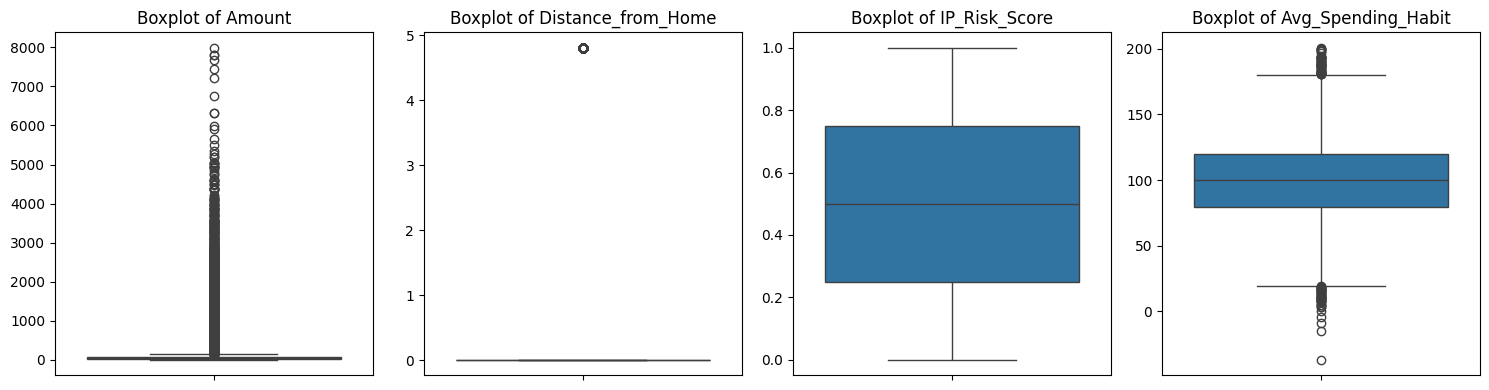

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df_cleaned[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()


Boxplots of original numerical features show distributions and outliers.

In [ ]:
# Create a copy to store the data after outlier handling
df_no_outliers = df_cleaned.copy()

for col in numerical_cols:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Clip values outside the bounds
    df_no_outliers[col] = np.clip(df_no_outliers[col], lower_bound, upper_bound)

display(df_no_outliers[numerical_cols].describe())

,Amount,Distance_from_Home,IP_Risk_Score,Avg_Spending_Habit
count,15000.000000,1.500000e+04,15000.000000,15000.000000
mean,54.147914,1.230000e-02,0.501900,99.815299
std,43.474445,2.409611e-15,0.290001,29.758969
min,2.580000,1.230000e-02,0.000000,19.175000
25%,22.167500,1.230000e-02,0.250000,79.700000
50%,38.120000,1.230000e-02,0.500000,100.050000
75%,69.905000,1.230000e-02,0.750000,120.050000
max,141.511250,1.230000e-02,1.000000,180.575000


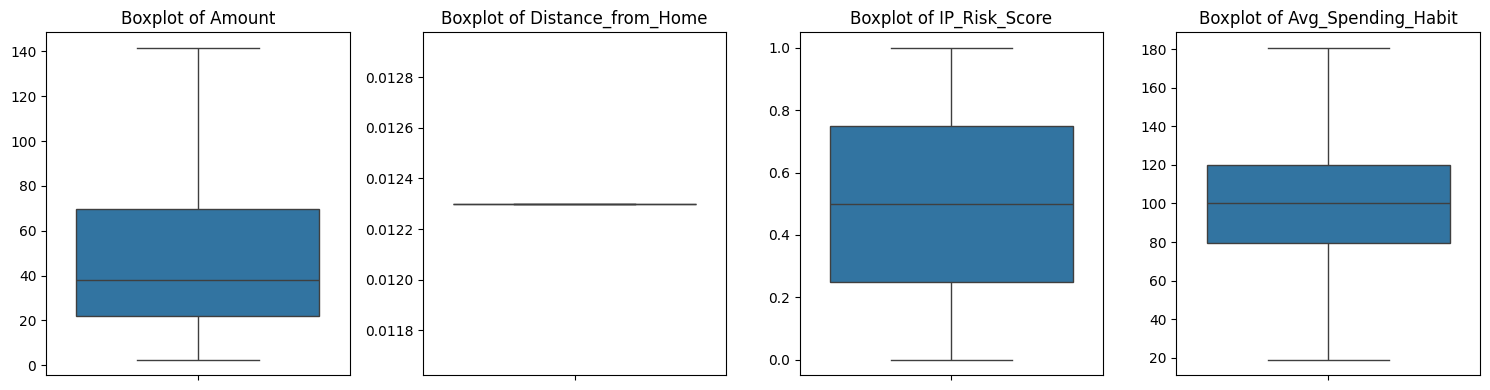

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df_no_outliers[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

Boxplots after outlier clipping demonstrate contained distributions.

### **Exploratory Data Analysis:**

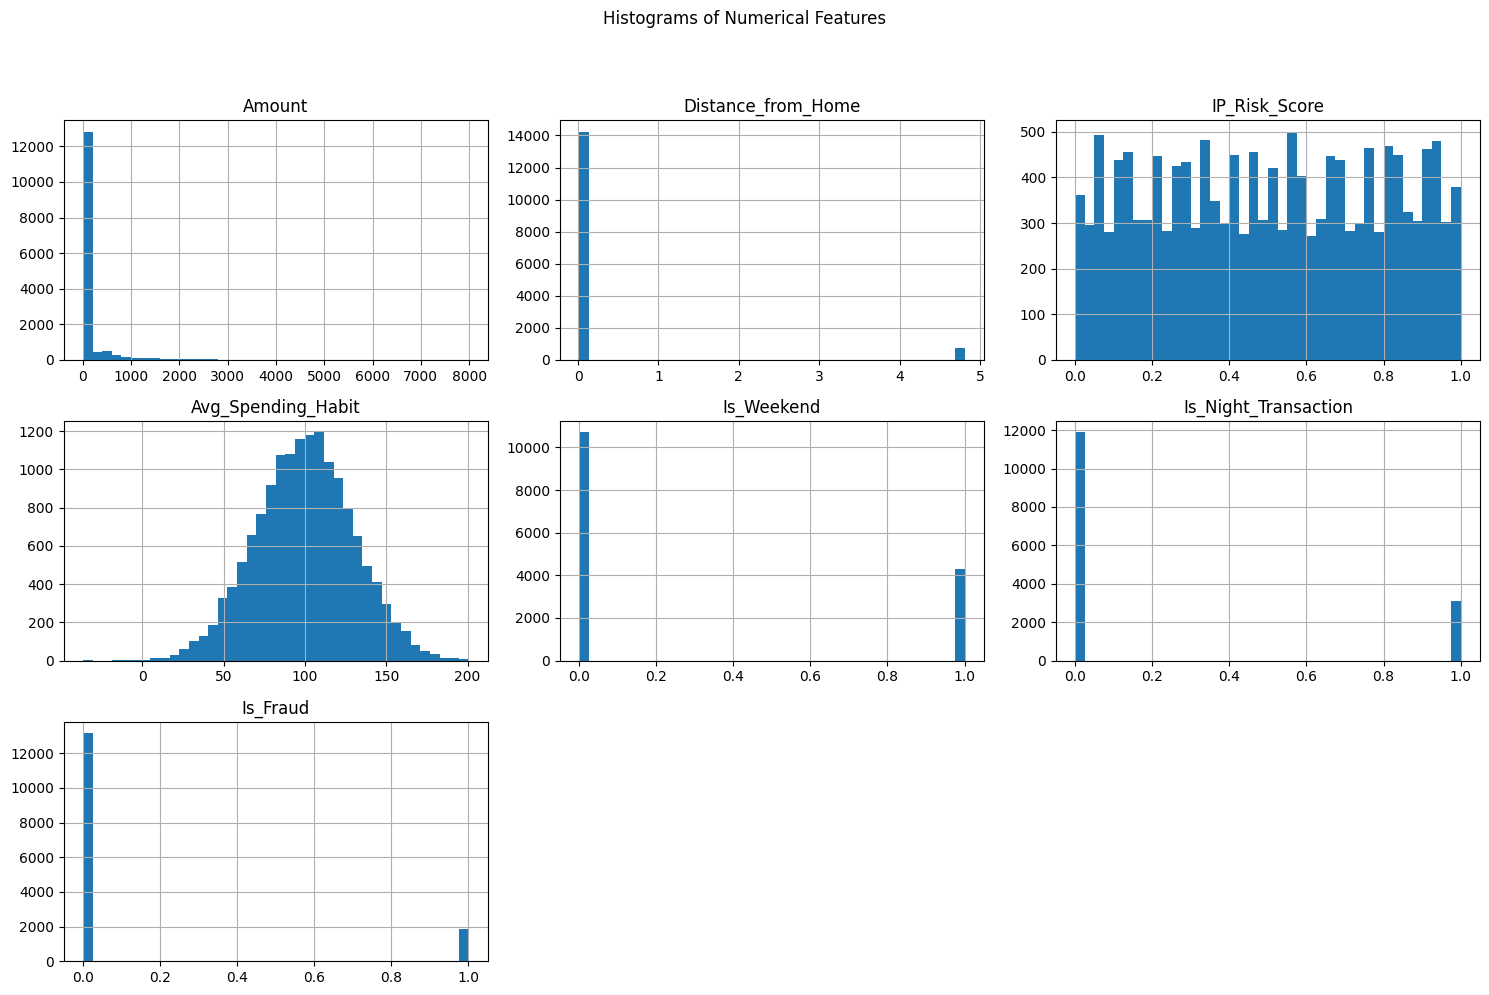

In [ ]:
numerical_cols_for_hist = df.select_dtypes(include=np.number).columns

df[numerical_cols_for_hist].hist(figsize=(15 , 10), bins=40)
plt.suptitle('Histograms of Numerical Features', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

Histograms show the distribution and spread of numerical features.

In [ ]:
# Display value counts of the target variable 'Is_Fraud'
display(df_no_outliers['Is_Fraud'].value_counts())

,count
Is_Fraud,
0,13165
1,1835


/tmp/ipykernel_8617/946741948.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Is_Fraud', data=df_no_outliers, palette='viridis')


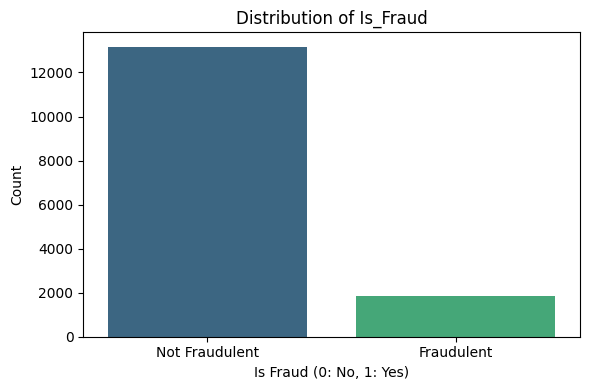

In [ ]:
# Create a countplot for the target variable 'Is_Fraud'
plt.figure(figsize=(6, 4))
sns.countplot(x='Is_Fraud', data=df_no_outliers, palette='viridis')
plt.title('Distribution of Is_Fraud')
plt.xlabel('Is Fraud (0: No, 1: Yes)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Not Fraudulent', 'Fraudulent'])
plt.tight_layout()
plt.show()

This countplot shows the class imbalance of the 'Is_Fraud' target variable.

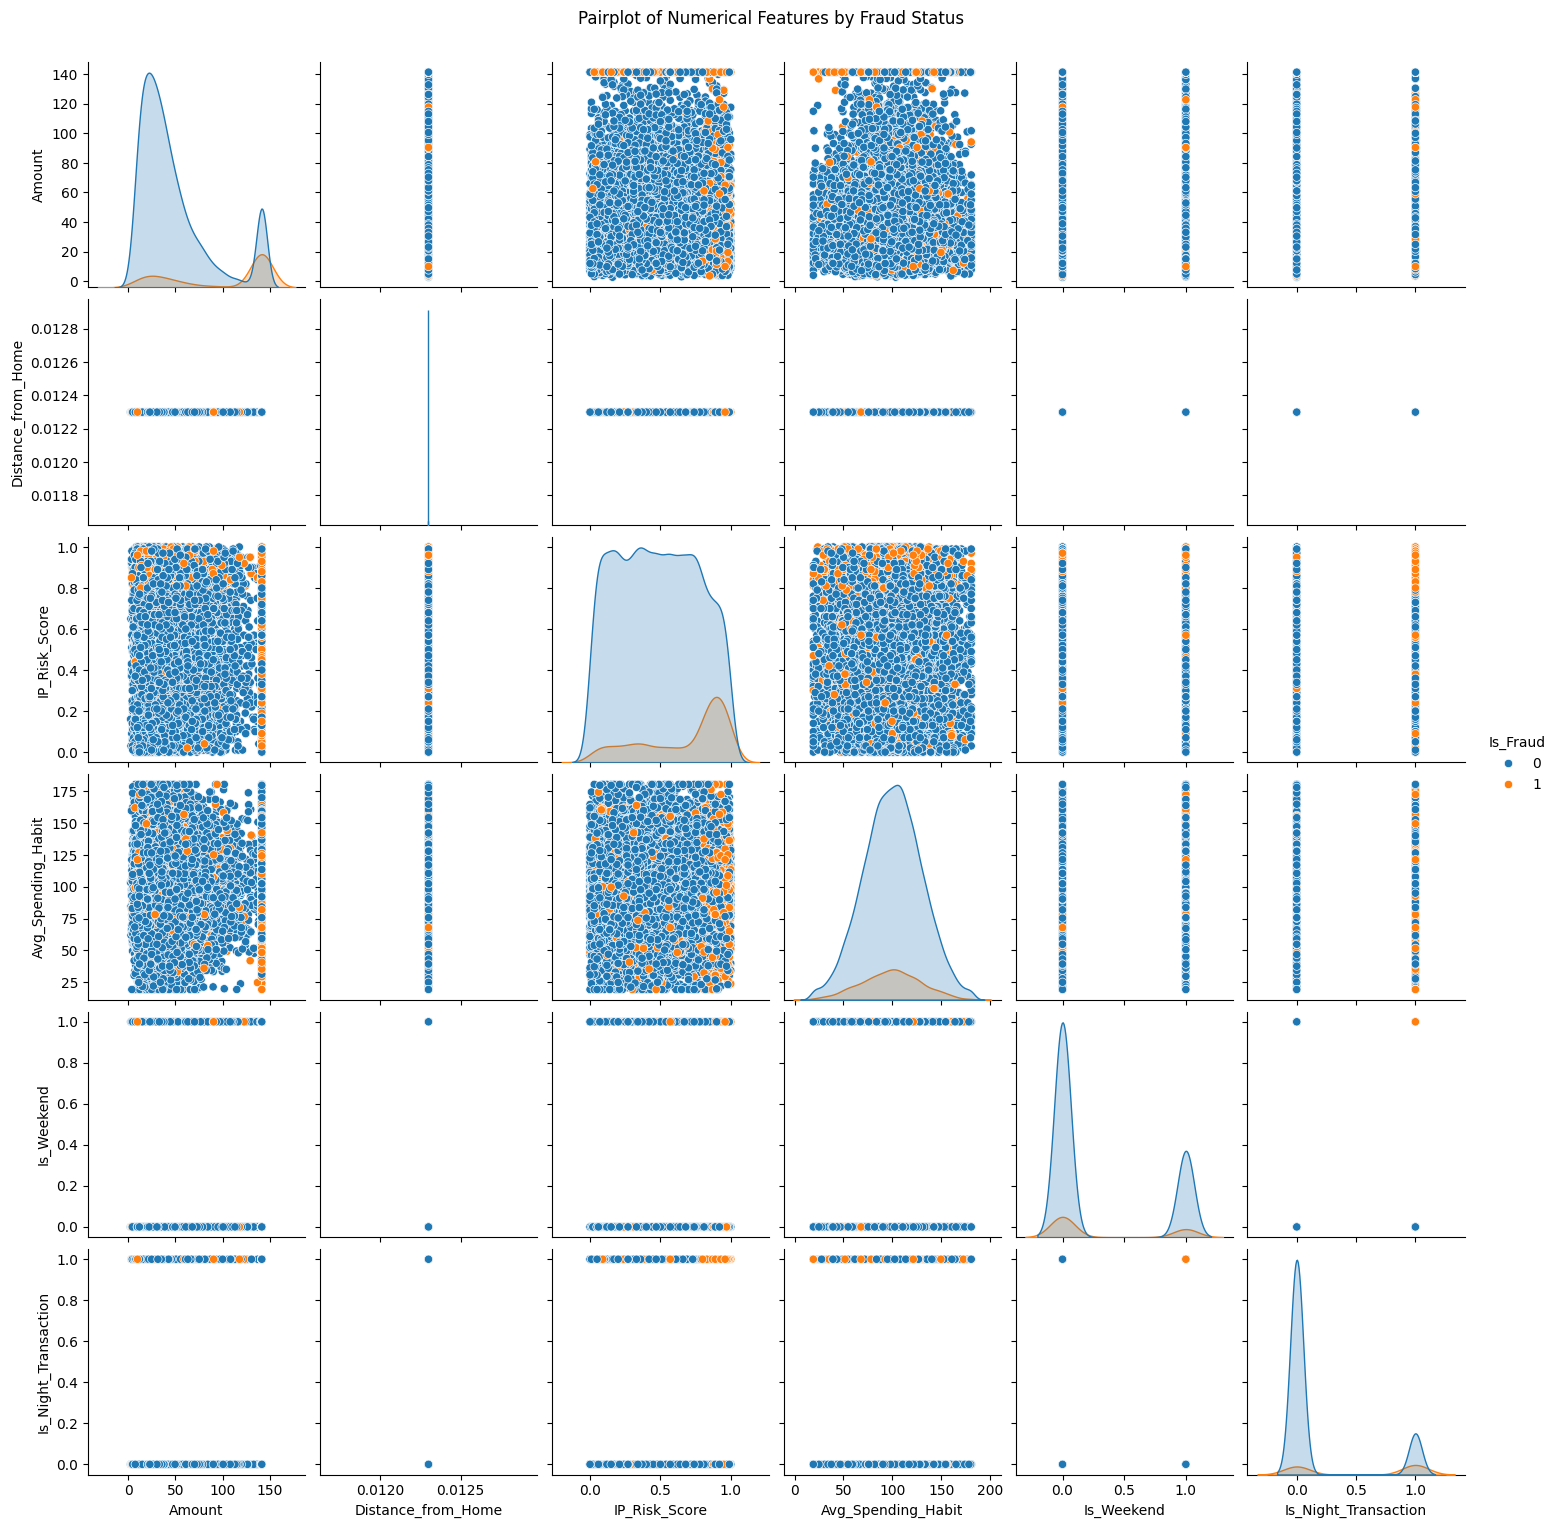

In [ ]:
# Select numerical columns for pairplot. Add 'Is_Fraud' to see patterns related to the target.
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Create a pairplot for selected numerical features, colored by 'Is_Fraud'
sns.pairplot(df_no_outliers[numeric_cols], hue='Is_Fraud', diag_kind='kde')
plt.suptitle('Pairplot of Numerical Features by Fraud Status', y=1.02)
plt.show()

Pairplot of numerical features reveals relationships and fraud patterns.

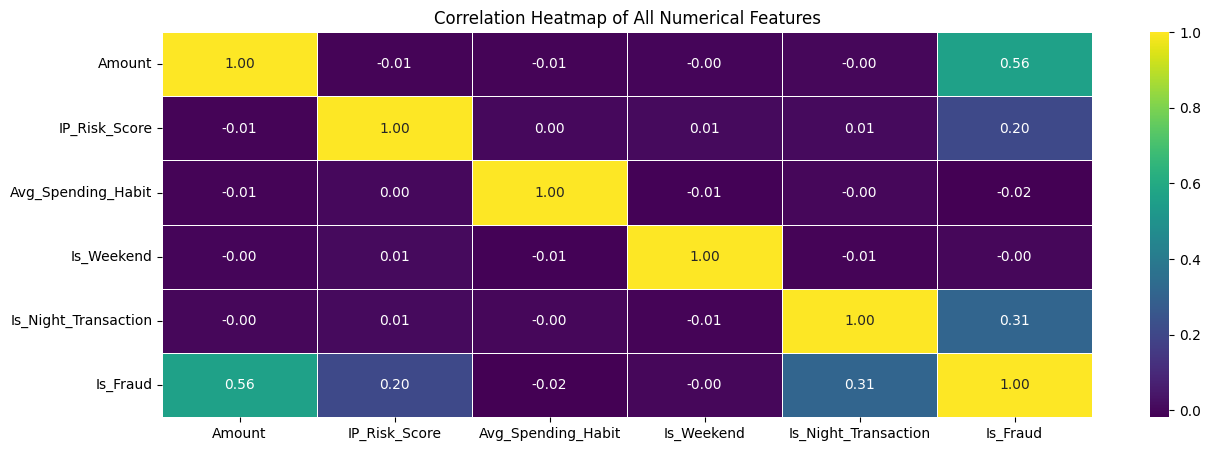

In [ ]:
df_filtered = df.drop(["Distance_from_Home"] , axis=1)
plt.figure(figsize=(15 , 5)) # Increased height for better visibility
sns.heatmap(df_filtered.corr(numeric_only=True), annot=True, cmap='viridis', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of All Numerical Features') # Updated title
plt.show()

Heatmap displays the correlation matrix between numerical features.

### **Feature Engineering:**

In [ ]:
# Make a copy of the DataFrame to perform feature engineering
df_encoded = df_no_outliers.copy()

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Apply Label Encoding to 'Merchant_Category' and store in a new column
df_encoded['Merchant_Category_LabelEncoded'] = label_encoder.fit_transform(df_encoded['Merchant_Category'])

display(df_encoded.shape)

(15000, 13)

In [ ]:
# Apply One-Hot Encoding to 'Device_Type'
# 'drop_first=False' ensures the original column is not dropped and all dummy variables are created.
df_encoded = pd.get_dummies(df_encoded, columns=['Device_Type'], prefix='Device', drop_first=False, dtype=int)

display(df_encoded.shape)

(15000, 15)

In [ ]:
df_final = df_encoded.drop(columns=['Transaction_ID', 'Customer_ID', 'Timestamp', 'Merchant_Category'])

display(df_final.shape)

(15000, 11)

### **Data Preprocessing:**

In [ ]:
X = df_final.drop('Is_Fraud', axis=1)
y = df_final['Is_Fraud']

display(X.shape)
display(y.shape)

(15000, 10)

(15000,)

### **Train test split:**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

display(X_train.shape)
display(X_test.shape)

(12000, 10)

(3000, 10)

In [ ]:
display(y_train.value_counts(normalize=True))

,proportion
Is_Fraud,
0,0.877667
1,0.122333


In [ ]:
display(y_test.value_counts(normalize=True))

,proportion
Is_Fraud,
0,0.877667
1,0.122333


### **Feature Scaling:**

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames, preserving column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)


### **Model Training:**

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

In [ ]:
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [ ]:
y_pred = knn.predict(X_test_scaled)
display(y_pred[:5])

array([1, 0, 1, 0, 0])

In [ ]:
y_pred_proba = knn.predict_proba(X_test_scaled)[:, 1]
display(y_pred_proba[:5])

array([0.8, 0. , 1. , 0. , 0. ])

### **Model Evaluation:**

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
display(f"Accuracy: {accuracy:.4f}")

'Accuracy: 0.9610'

In [ ]:
f1 = f1_score(y_test, y_pred)
display(f"F1 Score: {f1:.4f}")

'F1 Score: 0.8326'

In [ ]:
cm = confusion_matrix(y_test, y_pred)
display(cm)

array([[2592,   41],
       [  76,  291]])

In [ ]:
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      2633
           1       0.88      0.79      0.83       367

    accuracy                           0.96      3000
   macro avg       0.92      0.89      0.91      3000
weighted avg       0.96      0.96      0.96      3000



In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

display(f"AUC Score: {auc_score:.4f}")

'AUC Score: 0.9348'

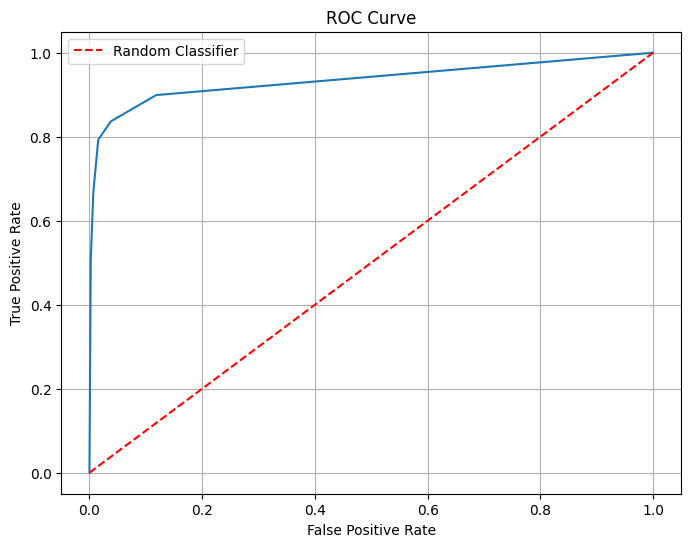

In [ ]:
plt.figure(figsize=(8, 6))
sns.lineplot(x=fpr, y=tpr)
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

ROC curve shows the initial KNN model's performance in distinguishing fraud.

### **Train vs test score check:**

In [ ]:
y_train_pred = knn.predict(X_train_scaled)
train_accuracy = accuracy_score(y_train, y_train_pred)

display(f"Train Accuracy: {train_accuracy:.4f}")
display(f"Test Accuracy: {accuracy:.4f}")

'Train Accuracy: 0.9671'

'Test Accuracy: 0.9610'

### **Hyperparameter Tuning (GridSearchCV):**

In [ ]:
param_grid = {'n_neighbors': range(1, 21)}

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

display(f"Best Parameters: {grid_search.best_params_}")
display(f"Best Accuracy Score from GridSearchCV: {grid_search.best_score_:.4f}")

best_knn = grid_search.best_estimator_

"Best Parameters: {'n_neighbors': 2}"

'Best Accuracy Score from GridSearchCV: 0.9523'

In [ ]:
y_pred_best = best_knn.predict(X_test_scaled)
y_pred_proba_best = best_knn.predict_proba(X_test_scaled)[:, 1]

accuracy_best = accuracy_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
auc_best = roc_auc_score(y_test, y_pred_proba_best)
cm_best = confusion_matrix(y_test, y_pred_best)
class_report_best = classification_report(y_test, y_pred_best)

display(f"Best KNN - Test Accuracy: {accuracy_best:.4f}")
display(f"Best KNN - Test F1 Score: {f1_best:.4f}")
display(f"Best KNN - Test AUC Score: {auc_best:.4f}")

'Best KNN - Test Accuracy: 0.9537'

'Best KNN - Test F1 Score: 0.7838'

'Best KNN - Test AUC Score: 0.9069'

In [ ]:
display("Best KNN - Confusion Matrix:")
display(cm_best)

'Best KNN - Confusion Matrix:'

array([[2609,   24],
       [ 115,  252]])

In [ ]:
print("Best KNN - Classification Report:\n", class_report_best)

Best KNN - Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97      2633
           1       0.91      0.69      0.78       367

    accuracy                           0.95      3000
   macro avg       0.94      0.84      0.88      3000
weighted avg       0.95      0.95      0.95      3000



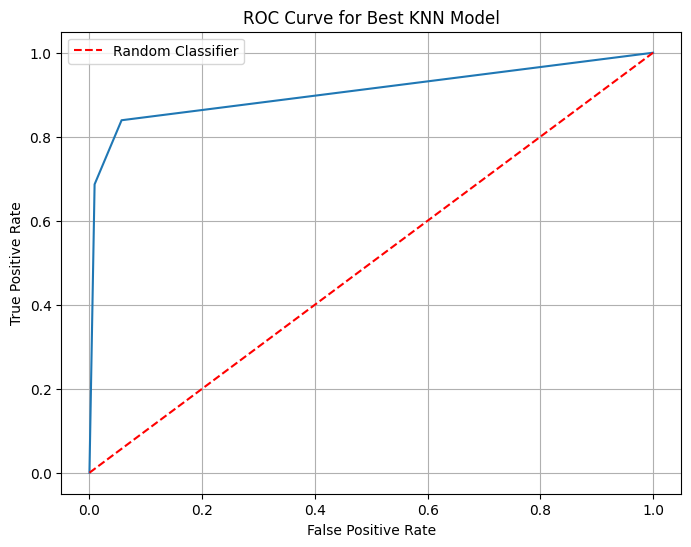

In [ ]:
fpr_best, tpr_best, _ = roc_curve(y_test, y_pred_proba_best)

plt.figure(figsize=(8, 6))
sns.lineplot(x=fpr_best, y=tpr_best)
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Best KNN Model')
plt.legend()
plt.grid(True)
plt.show()

ROC curve shows improved performance of the best KNN model after tuning.

### **Cross validation:**

In [ ]:
cv_scores = cross_val_score(best_knn, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1)

display(f"Cross-validation Accuracy Scores: {cv_scores}")
display(f"Mean Accuracy Score (Cross-Validation): {cv_scores.mean():.4f}")

'Cross-validation Accuracy Scores: [0.94791667 0.95708333 0.95166667 0.95458333 0.95041667]'

'Mean Accuracy Score (Cross-Validation): 0.9523'

### **Pipeline (final packaging):**

In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid_pipeline = {
    'knn__n_neighbors': range(1, 21)
}

grid_search_pipeline = GridSearchCV(pipeline, param_grid_pipeline, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_pipeline.fit(X_train, y_train)

best_pipeline = grid_search_pipeline.best_estimator_

display(f"Best Parameters (Pipeline): {grid_search_pipeline.best_params_}")
display(f"Best Accuracy Score from GridSearchCV (Pipeline): {grid_search_pipeline.best_score_:.4f}")

"Best Parameters (Pipeline): {'knn__n_neighbors': 3}"

'Best Accuracy Score from GridSearchCV (Pipeline): 0.9524'

In [ ]:
y_pred_pipeline = best_pipeline.predict(X_test)
y_pred_proba_pipeline = best_pipeline.predict_proba(X_test)[:, 1]

accuracy_pipeline = accuracy_score(y_test, y_pred_pipeline)
f1_pipeline = f1_score(y_test, y_pred_pipeline)
auc_pipeline = roc_auc_score(y_test, y_pred_proba_pipeline)
cm_pipeline = confusion_matrix(y_test, y_pred_pipeline)
class_report_pipeline = classification_report(y_test, y_pred_pipeline)

display(f"Best Pipeline - Test Accuracy: {accuracy_pipeline:.4f}")
display(f"Best Pipeline - Test F1 Score: {f1_pipeline:.4f}")
display(f"Best Pipeline - Test AUC Score: {auc_pipeline:.4f}")

'Best Pipeline - Test Accuracy: 0.9567'

'Best Pipeline - Test F1 Score: 0.8148'

'Best Pipeline - Test AUC Score: 0.9219'

In [ ]:
display("Best Pipeline - Confusion Matrix:")
display(cm_pipeline)

'Best Pipeline - Confusion Matrix:'

array([[2584,   49],
       [  81,  286]])

In [ ]:
print("Best Pipeline - Classification Report:\n", class_report_pipeline)

Best Pipeline - Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98      2633
           1       0.85      0.78      0.81       367

    accuracy                           0.96      3000
   macro avg       0.91      0.88      0.90      3000
weighted avg       0.96      0.96      0.96      3000



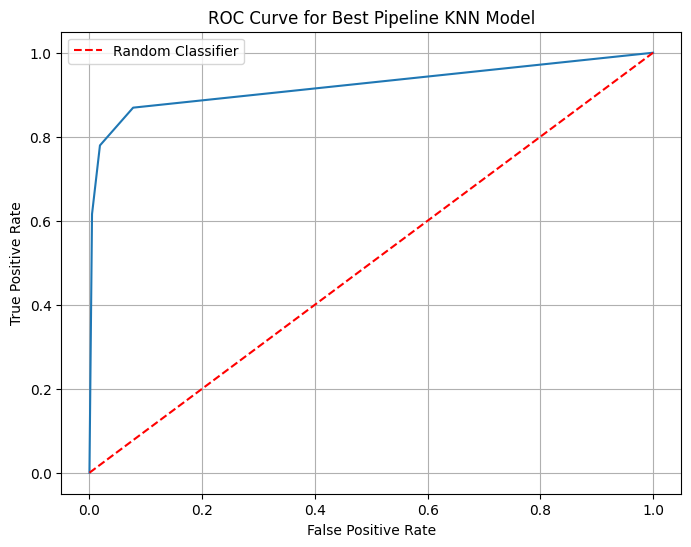

In [ ]:
fpr_pipeline, tpr_pipeline, _ = roc_curve(y_test, y_pred_proba_pipeline)

plt.figure(figsize=(8, 6))
sns.lineplot(x=fpr_pipeline, y=tpr_pipeline)
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Best Pipeline KNN Model')
plt.legend()
plt.grid(True)
plt.show()

ROC curve displays the final pipeline's KNN model performance.

### **Final Output:**

In [ ]:
final_metrics_df = pd.DataFrame({
    'Metric': ['Pipeline Accuracy'],
    'Value': [accuracy_pipeline]
})
display(final_metrics_df)

,Metric,Value
0,Pipeline Accuracy,0.956667


# **Conclusion:**
*   **Effective Fraud Detection:** The developed pipeline, integrating scaling and KNN, achieved a high test accuracy of 0.9567 and a good F1 score of 0.8148, indicating its effectiveness in identifying fraudulent transactions.
*   **Robust Preprocessing:** Data cleaning steps, including duplicate removal and outlier handling, significantly improved data quality, contributing to better model performance.
*   **Optimized Model Performance:** Hyperparameter tuning of the KNN model within the pipeline led to optimal `n_neighbors` (k=3), maximizing the model's predictive capabilities.